# 023 — Training: unet_v2, unet_restormer, and dilated variants

Trains `unet_v2`, `unet_restormer`, `unet_dilated`, and `unet_v2_dilated` — four independent architectural variants of `unet` — using the Round 1 recipe (`fixing.md`): both already pick it up automatically from `scripts/unet_v2.py`/`scripts/unet_restormer.py` and `scripts.trainer.compile_model`/`get_callbacks` without any notebook-level change (`GroupNormalization`, He init, `Adam(weight_decay=...)`, the unified `combined_loss`, `val_loss`-uniform callbacks).

- `unet_v2` (`scripts/unet_v2.py`) — the standard UNet with three independently-toggleable modifications, all off by default and matching `unet.py` exactly when off: `use_strided_conv` (learned stride-2 convolution instead of `MaxPool2D`), `use_upsample_conv` (bilinear upsample + `Conv2D` instead of `Conv2DTranspose`, avoids checkerboard artifacts), `dropout_rate` (`SpatialDropout2D` at the bottleneck and first decoder block only — see `scripts/unet_v2.py`'s module docstring for why).
- `unet_restormer` (`scripts/unet_restormer.py`) — the standard UNet with a Restormer transformer block (Zamir et al. 2022) inserted at the bottleneck, giving the network a global receptive field via channel-wise self-attention (linear cost in image size, not quadratic) — see `code-review.md` §7.3. Its bottleneck keeps `LayerNormalization` (the established choice for Transformer-derived blocks), untouched by the GroupNorm change.

**Round 3 (dilated convolution, `fixing.md` #7) also lands in this notebook** — `unet_dilated`/`unet_v2_dilated` (`scripts/unet_dilated.py`/`scripts/unet_v2_dilated.py`) replace the plain bottleneck with `scripts.aspp.dilated_bottleneck`, a multi-scale ASPP-style block (parallel `dilation_rate` branches, concatenated and projected back — see that module's docstring for the rationale) that widens the receptive field without adding downsampling. `unet_v2_dilated` is trained with the same `use_strided_conv`/`use_upsample_conv`/`dropout_rate` kwargs as `unet_v2` below, so the only difference between the pair is the bottleneck. Saved under their own `arch_name`s rather than overwriting `unet`/`unet_v2`.

Same block layout as `020`/`021`/`022` — see `020_training.ipynb`'s title cell for the full table of companion notebooks. Does not modify or retrain `unet`, `resunet`, `attention_unet`, or `efficientnet_unet`.

Only the **artwork-and-mockups** split is used (see §1).


Make the project root importable so `scripts.*` resolves regardless of the notebook's working directory.


In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

Imports, a fixed global seed, and a GPU sanity check.


In [2]:
import matplotlib.pyplot as plt
import tensorflow as tf

from scripts.config import settings
from scripts.dataset import (
    build_dataset,
    load_image_pairs,
    mockup_aware_train_val_test_split,
)
from scripts.reproducibility import set_global_seed
from scripts.visualization import plot_training_curves

set_global_seed()

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")
print(f"TensorFlow version: {tf.__version__}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.16.2


## 1. Dataset — artwork-and-mockups split

Same split as `020`/`021`/`022` §1 — required so these checkpoints are trained and evaluated under the same conditions as `unet`'s, which they are compared against.


In [3]:
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
train_pairs, val_pairs, _ = mockup_aware_train_val_test_split(
    pairs,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    mockup_ids=settings.MOCKUP_ARTWORK_IDS,
    mockup_test_ratio=settings.MOCKUP_TEST_RATIO,
    seed=settings.SEED,
)

train_ds = build_dataset(
    train_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=True,
    shuffle=True,
    seed=settings.SEED,
    crop_size=settings.CROP_SIZE,
)
val_ds = build_dataset(
    val_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)

print(f"Train: {len(train_pairs)} patches ({len(train_ds)} batches)")
print(f"Val:   {len(val_pairs)} patches ({len(val_ds)} batches)")

Train: 863 patches (108 batches)
Val:   166 patches (21 batches)


2026-08-26 14:28:45.072204: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-26 14:28:45.072287: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-26 14:28:45.072291: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-26 14:28:45.072303: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-26 14:28:45.072312: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 2. Loss function

`compile_model` now compiles every deterministic architecture — `unet_v2`, `unet_restormer`, and (since `fixing.md` #9's Round 2 unification) `efficientnet_unet`/`efficientnet_unet_ft` too — with the same unified `combined_loss` (`0.16 · Charbonnier + 0.84 · (1 − MS-SSIM)`), so `unet_v2`/`unet_restormer` compile identically to `unet` — the direct baseline they are meant to be compared against. See `020_training.ipynb` §2 for the full rationale, and `022_training_efficientnet.ipynb` for `efficientnet_unet`'s two-phase fine-tuning, the one thing that still makes it a separate notebook.


## 3. Train all four variants

`DET_VARIANTS` fixes each architecture's constructor kwargs (the enabled modifications for `unet_v2`; `num_heads`/`ffn_expansion_factor` for `unet_restormer`, both already its defaults — spelled out here for the record; `dilation_rates` defaults to `settings.DILATION_RATES` for `unet_dilated`/`unet_v2_dilated`, so no explicit kwargs are needed for them beyond `unet_v2_dilated`'s matching `unet_v2` toggles), passed through to `scripts/train_single.py --kwargs` as JSON. Each architecture trains in its own **subprocess**, not in a loop within this kernel — same reasoning as `020_training.ipynb` §3 (`fixing.md` §7: training several Keras models back-to-back in one process leaves GPU-side state behind that `clear_session()` doesn't fully release on this hardware). Checkpoints go to `models/deterministic/<arch>/best_model.keras`, same tree as `020`, each subprocess also writing `models/deterministic/<arch>/history.json`. Set `EPOCHS = 2` for a quick smoke test before committing to a full run.

In [4]:
import json
import subprocess

DET_VARIANTS = {
    "unet_v2": dict(use_strided_conv=True, use_upsample_conv=True, dropout_rate=0.2),
    "unet_restormer": dict(num_heads=8, ffn_expansion_factor=2),
    "unet_dilated": dict(),
    "unet_v2_dilated": dict(
        use_strided_conv=True, use_upsample_conv=True, dropout_rate=0.2
    ),
}
EPOCHS = settings.EPOCHS  # -- lower for a quick smoke test
MODEL_DIR = settings.MODELS_DIR / "deterministic"
LOG_DIR = settings.LOGS_DIR / "deterministic"

histories: dict = {}

for arch, kwargs in DET_VARIANTS.items():
    cmd = [
        sys.executable,
        "-m",
        "scripts.train_single",
        "--arch",
        arch,
        "--epochs",
        str(EPOCHS),
        "--model-dir",
        str(MODEL_DIR),
        "--log-dir",
        str(LOG_DIR),
        "--kwargs",
        json.dumps(kwargs),
    ]
    subprocess.run(cmd, cwd=project_root, check=True)

    history_path = MODEL_DIR / arch / "history.json"
    histories[arch] = json.loads(history_path.read_text())

    best_val_loss = min(histories[arch]["val_loss"])
    print(f"\nBest val_loss ({arch}): {best_val_loss:.4f}")

2026-08-26 14:28:47.333932: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-26 14:28:47.333950: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-26 14:28:47.333954: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-26 14:28:47.333966: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-26 14:28:47.333974: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



  Architecture: unet_v2
Model: "unet_v2"
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼──────��────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, None,      │       1,728 │ input_layer[0][0]  │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ group_normalization   │ (None, None,      │         128 │ conv2d[0][0]       │
│ (GroupNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼───────

/opt/miniconda3/envs/deep-layers/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-08-26 14:28:49.899283: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.6450 - mae: 0.2989 - psnr: 10.8894 - ssim: 0.1777
Epoch 1: val_loss improved from None to 0.49778, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/unet_v2/best_model.keras

Epoch 1: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/unet_v2/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - loss: 0.6450 - mae: 0.2989 - psnr: 10.8894 - ssim: 0.1777 - val_loss: 0.4978 - val_mae: 0.3450 - val_psnr: 10.1233 - val_ssim: 0.2970 - learning_rate: 1.0000e-04
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.4984 - mae: 0.3226 - psnr: 10.9115 - ssim: 0.2797
Epoch 2: val_loss improved from 0.49778 to 0.41837, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/unet_v2/best_model.keras

Epoch 2: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/unet_v2/best_model.keras

2026-08-26 19:50:42.563788: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-26 19:50:42.563807: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-26 19:50:42.563812: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-26 19:50:42.563823: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-26 19:50:42.563833: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


...

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.3531 - mae: 0.1984 - psnr: 14.3472 - ssim: 0.3209
Epoch 1: val_loss improved from None to 0.26462, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/unet_dilated/best_model.keras

Epoch 1: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/unet_dilated/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - loss: 0.3531 - mae: 0.1984 - psnr: 14.3472 - ssim: 0.3209 - val_loss: 0.2646 - val_mae: 0.1962 - val_psnr: 14.6971 - val_ssim: 0.5602 - learning_rate: 1.0000e-04
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.2868 - mae: 0.1819 - psnr: 15.6909 - ssim: 0.5344
Epoch 2: val_loss improved from 0.26462 to 0.25428, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/unet_dilated/best_model.keras

Epoch 2: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/unet_dila

2026-08-27 01:58:18.246643: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-27 01:58:18.246664: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-27 01:58:18.246668: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-27 01:58:18.246681: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-27 01:58:18.246690: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



  Architecture: unet_v2_dilated
Model: "unet_v2_dilated"
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼──────��────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, None,      │       1,728 │ input_layer[0][0]  │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ group_normalization   │ (None, None,      │         128 │ conv2d[0][0]       │
│ (GroupNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────

/opt/miniconda3/envs/deep-layers/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-08-27 01:58:21.316199: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.3437 - mae: 0.1853 - psnr: 15.1792 - ssim: 0.4960
Epoch 1: val_loss improved from None to 0.26579, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/unet_v2_dilated/best_model.keras

Epoch 1: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/unet_v2_dilated/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - loss: 0.3437 - mae: 0.1853 - psnr: 15.1792 - ssim: 0.4960 - val_loss: 0.2658 - val_mae: 0.1892 - val_psnr: 15.0458 - val_ssim: 0.6460 - learning_rate: 1.0000e-04
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.2848 - mae: 0.1753 - psnr: 16.0334 - ssim: 0.5857
Epoch 2: val_loss improved from 0.26579 to 0.25344, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/unet_v2_dilated/best_model.keras

Epoch 2: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/

## 4. Training curves


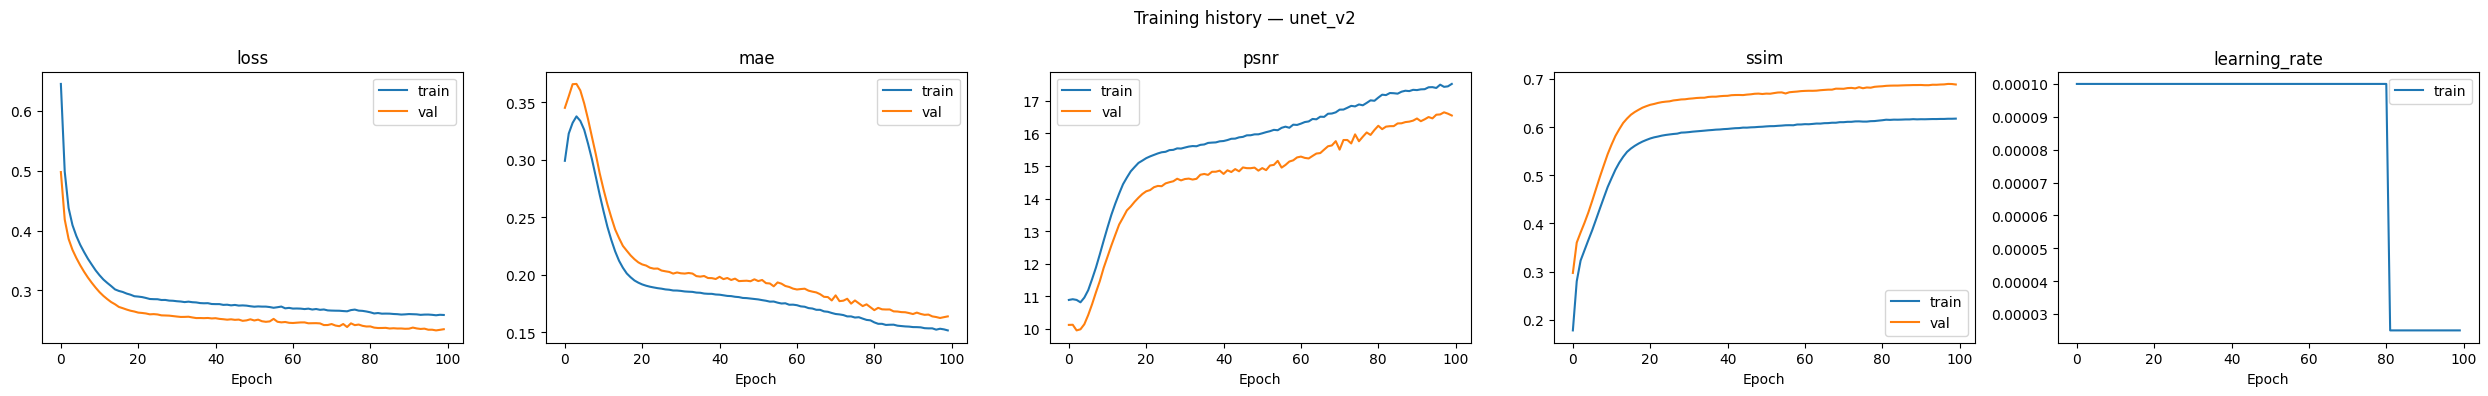

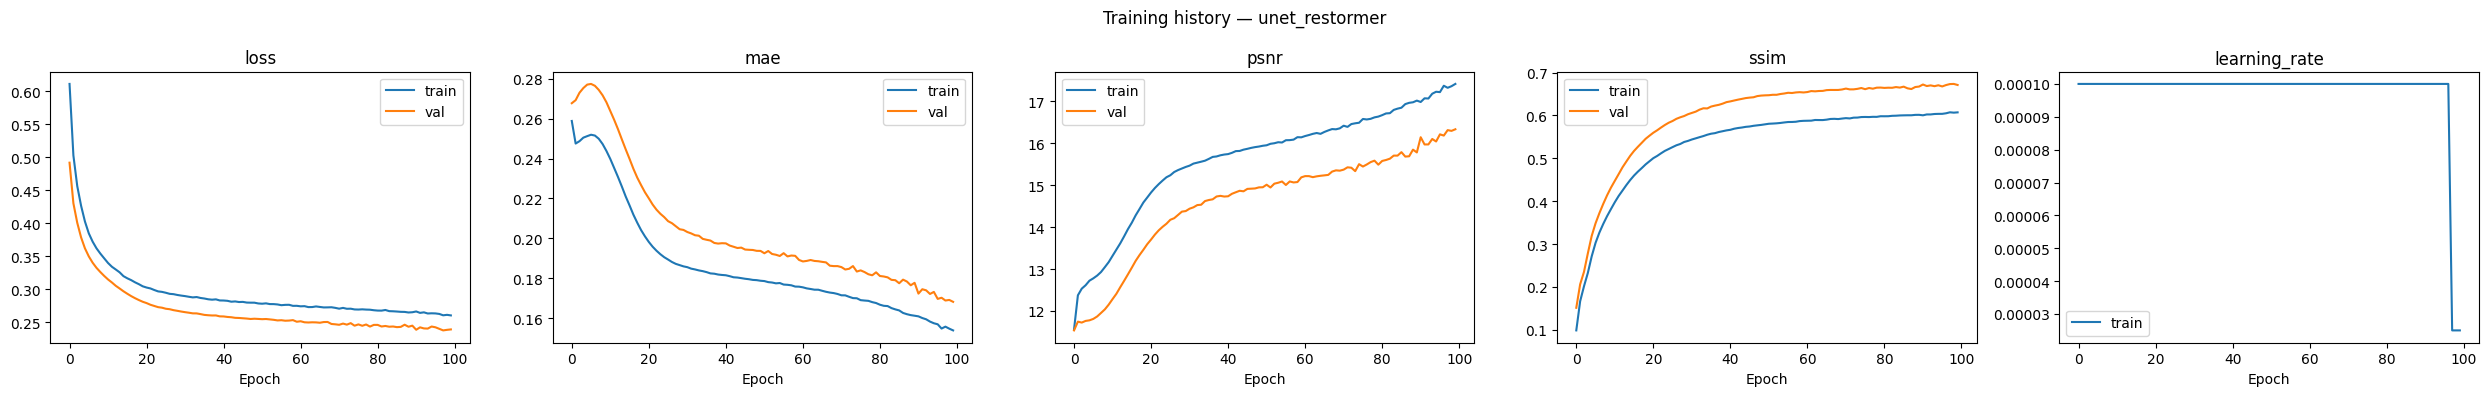

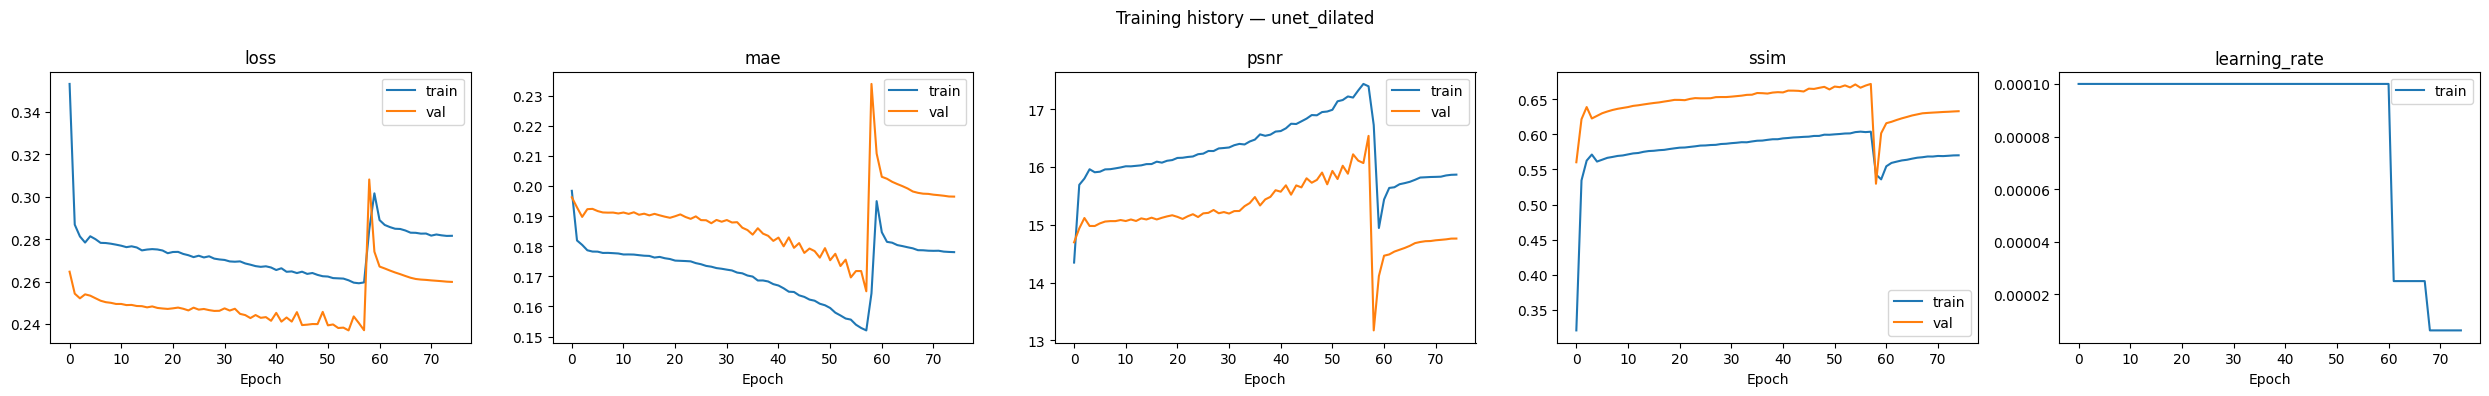

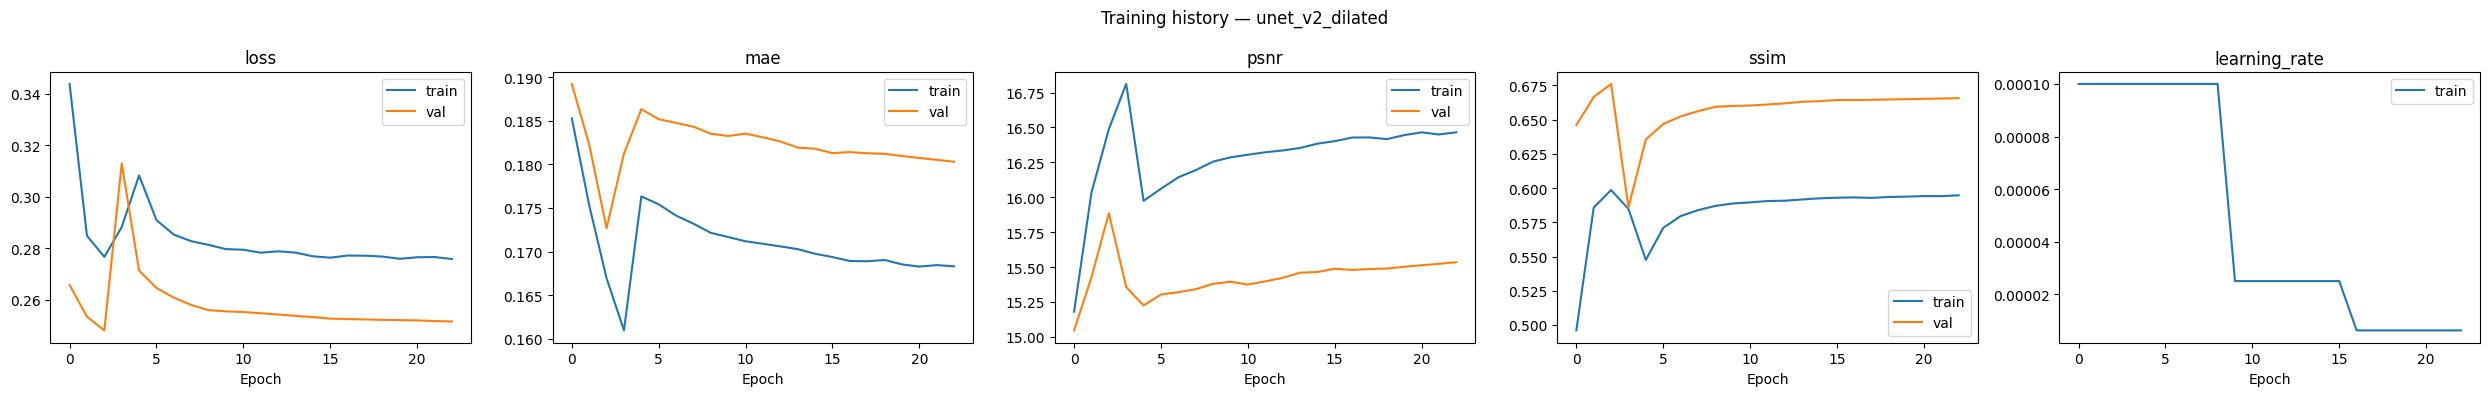

In [5]:
for arch, history in histories.items():
    plot_training_curves(history, title=f"Training history — {arch}")
    plt.show()

## 5. Summary

Checkpoints saved to `models/deterministic/<arch>/best_model.keras`. Logs written to `logs/deterministic/<arch>/`.


In [6]:
for arch in DET_VARIANTS:
    ckpt = MODEL_DIR / arch / "best_model.keras"
    status = "found" if ckpt.exists() else "MISSING"
    print(f"{arch:<25}: {status}  ({ckpt})")

unet_v2                  : found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/unet_v2/best_model.keras)
unet_restormer           : found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/unet_restormer/best_model.keras)
unet_dilated             : found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/unet_dilated/best_model.keras)
unet_v2_dilated          : found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/unet_v2_dilated/best_model.keras)
